# Atividade Prática 3

Aluno: João Gabriel Angelo Bradachi

Professor: Fabrício Silva

Objetivo: Aplicar técnicas de transformação nos dados para melhorar treinamento de Modelos


In [6]:
! pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 3.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 2.4 MB/s eta 0:00:00m eta 0:00:010:00:07


In [3]:
import pandas as pd
import numpy as np
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler


# Churn Bank

In [3]:
churn_raw = pd.read_csv("Churn_Bank.csv")
churn_raw

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
churn_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [12]:
churn_raw.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


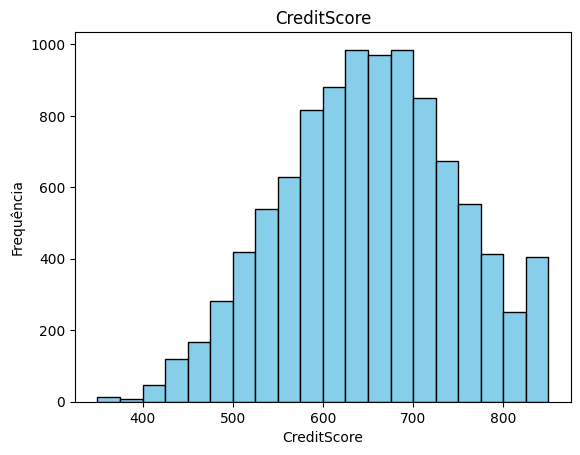

In [18]:
plt.hist(churn_raw['CreditScore'], bins=20, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('CreditScore')
plt.xlabel('CreditScore')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

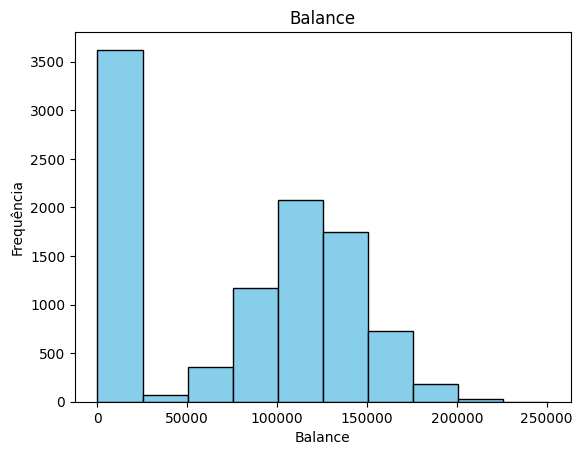

In [9]:
plt.hist(churn_raw['Balance'], bins=10, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('Balance')
plt.xlabel('Balance')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

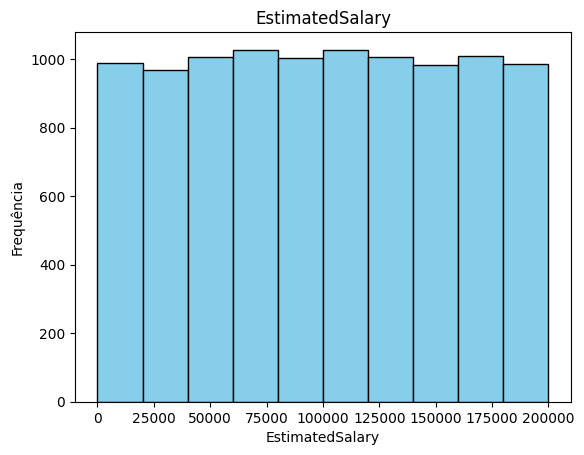

In [8]:
plt.hist(churn_raw['EstimatedSalary'], bins=10, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('EstimatedSalary')
plt.xlabel('EstimatedSalary')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

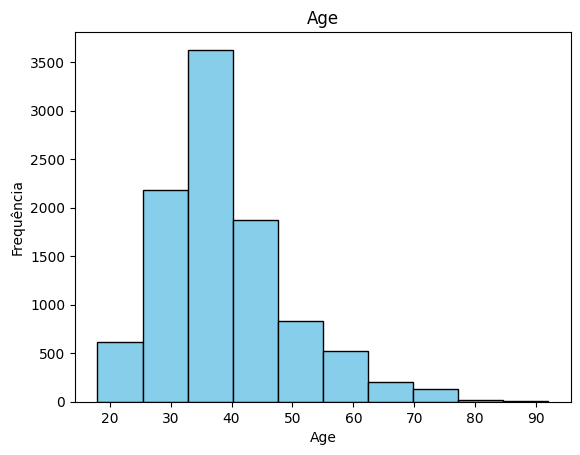

In [7]:
plt.hist(churn_raw['Age'], bins=10, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('Age')
plt.xlabel('Age')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

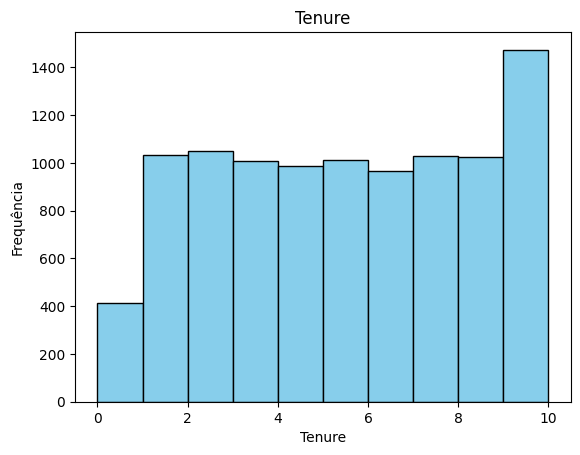

In [25]:
plt.hist(churn_raw['Tenure'], bins=10, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('Tenure')
plt.xlabel('Tenure')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

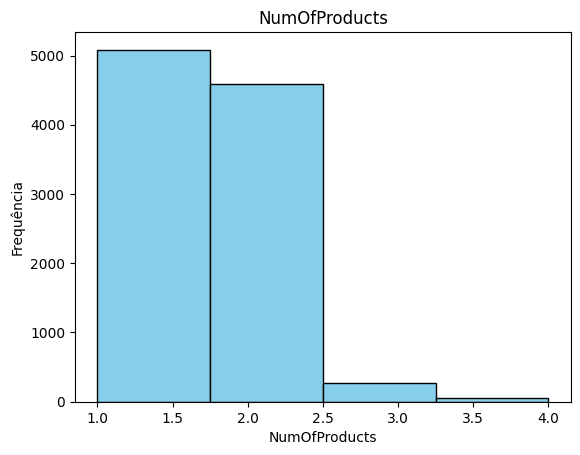

In [27]:
plt.hist(churn_raw['NumOfProducts'], bins=4, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('NumOfProducts')
plt.xlabel('NumOfProducts')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

## Análise prévia dos dados
* algumas colunas são booleanas, HasCrCard, IsActiveMember, Exited
* Tenure e num of products podem ser categóricas 
* podemos colocar balance, age, creditScore e EstimatedSalary em bins
* podemos remover RowNumber e CostumerID
* podemos criar uma categoria a mais no surname juntando todos os sobrenomes que aparecem apenas uma vez (chamar de "outros")

Mas vamos tentar fazer a previsão usando o dataset todo sem nenhuma engenharia de dados. Vamos usar o XGBoost

In [8]:
df_nao_tratado = churn_raw.dropna()
df_nao_tratado

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [15]:


X = df_nao_tratado.drop('Exited', axis=1) 
y = df_nao_tratado['Exited']              

# Dividindo em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
y_treino = y_treino.astype(bool)

# Pega o nome das colunas numéricas (int e float)
colunas_numericas = X.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()

# Pega o nome das colunas categóricas (object/string)
colunas_categoricas = X.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

# Pipeline para categorias: aplica One-Hot Encoding
transformer_categorico = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # ignore: se aparecer uma categoria nova no teste, ele não quebra
])

# ColumnTransformer
pre_processador = ColumnTransformer(
    transformers=[
        ('cat', transformer_categorico, colunas_categoricas)
    ])

# Aqui conectamos o tratamento de dados ao modelo Random Forest
modelo_pipeline = Pipeline(steps=[
    ('pre_processamento', pre_processador),
    ('classificador', XGBClassifier(
        n_estimators=100,     # Número de árvores
        learning_rate=0.1,    # Velocidade de aprendizado (ajuda a não ter overfitting)
        max_depth=5,          # Profundidade máxima de cada árvore
        random_state=42
    ))
])

print("Treinando o modelo...")
modelo_pipeline.fit(X_treino, y_treino)

print("Fazendo previsões no conjunto de teste...")
previsoes = modelo_pipeline.predict(X_teste)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes, digits=5))

Treinando o modelo...
Fazendo previsões no conjunto de teste...

Relatório de Classificação:
              precision    recall  f1-score   support

           0    0.80390   1.00000   0.89129      1607
           1    1.00000   0.00254   0.00508       393

    accuracy                        0.80400      2000
   macro avg    0.90195   0.50127   0.44818      2000
weighted avg    0.84244   0.80400   0.71715      2000



## Melhorando a partir dos atributos numéricos

In [15]:
df_tratado = churn_raw.drop(columns=['CustomerId', 'RowNumber'])

df_tratado['Surname'] = df_tratado['Surname'].astype('str')      
df_tratado['CreditScore'] = df_tratado['CreditScore'].astype('int64')    
df_tratado['Geography'] = df_tratado['Geography'].astype('str')      
df_tratado['Gender'] = df_tratado['Gender'].astype('str')      
df_tratado['Age'] = df_tratado['Age'].astype('int64')    
df_tratado['Tenure'] = df_tratado['Tenure'].astype('int64')    
df_tratado['Balance'] = df_tratado['Balance'].astype('float64')  
df_tratado['NumOfProducts'] = df_tratado['NumOfProducts'].astype('str')    
df_tratado['HasCrCard'] = df_tratado['HasCrCard'].astype('bool')    
df_tratado['IsActiveMember'] = df_tratado['IsActiveMember'].astype('bool')    
df_tratado['EstimatedSalary'] = df_tratado['EstimatedSalary'].astype('float64')  
df_tratado['Exited'] = df_tratado['Exited'].astype('bool')

df_tratado.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Surname          10000 non-null  str    
 1   CreditScore      10000 non-null  int64  
 2   Geography        10000 non-null  str    
 3   Gender           10000 non-null  str    
 4   Age              10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  str    
 8   HasCrCard        10000 non-null  bool   
 9   IsActiveMember   10000 non-null  bool   
 10  EstimatedSalary  10000 non-null  float64
 11  Exited           10000 non-null  bool   
dtypes: bool(3), float64(2), int64(3), str(4)
memory usage: 911.7 KB


In [16]:
# vamos aplicar o binning em balance, age, creditScore e EstimatedSalary

df_tratado['Age_bin'] = pd.qcut(df_tratado['Age'], q=10, labels=False)

# df_tratado['Balance_bin'] = pd.qcut(df_tratado['Balance'], q=20, labels=False, duplicates='drop')

df_tratado['CreditScore_bin'] = pd.qcut(df_tratado['CreditScore'], q=20, labels=False)

# df_tratado['EstimatedSalary_bin'] = pd.qcut(df_tratado['EstimatedSalary'], q=20, labels=False, duplicates='drop')

df_tratado['Tenure_bin'] = pd.qcut(df_tratado['Tenure'], q=5, labels=False, duplicates='drop')

df_tratado


,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_bin,CreditScore_bin,Tenure_bin
0,Hargrave,619,France,Female,42,2,0.00,1,True,True,101348.88,True,6,7,0
1,Hill,608,Spain,Female,41,1,83807.86,1,False,True,112542.58,False,6,6,0
2,Onio,502,France,Female,42,8,159660.80,3,True,False,113931.57,True,6,1,3
3,Boni,699,France,Female,39,1,0.00,2,False,False,93826.63,False,5,13,0
4,Mitchell,850,Spain,Female,43,2,125510.82,1,True,True,79084.10,False,7,19,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Obijiaku,771,France,Male,39,5,0.00,2,True,False,96270.64,False,5,17,2
9996,Johnstone,516,France,Male,35,10,57369.61,1,True,True,101699.77,False,3,1,4
9997,Liu,709,France,Female,36,7,0.00,1,False,True,42085.58,True,4,14,3
9998,Sabbatini,772,Germany,Male,42,3,75075.31,2,True,False,92888.52,True,6,17,1


In [19]:
scaler = StandardScaler()

colunas_padronizar = ['Balance', 'EstimatedSalary']

transformer_numerico = Pipeline(steps=[
    ('num_std', StandardScaler()),
])

In [21]:
df_tratado_treino = df_tratado[['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited', "Age_bin", 'Balance', 'CreditScore_bin', 'EstimatedSalary']]

X = df_tratado_treino.drop('Exited', axis=1) 
y = df_tratado_treino['Exited']              

# Dividindo em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
y_treino = y_treino.astype(bool)

# Pega o nome das colunas numéricas (int e float)
colunas_numericas = X.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()

# Pega o nome das colunas categóricas (object/string)
colunas_categoricas = X.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

# Pipeline para categorias: aplica One-Hot Encoding
transformer_categorico = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # ignore: se aparecer uma categoria nova no teste, ele não quebra
])

# ColumnTransformer
pre_processador = ColumnTransformer(
    transformers=[
        ('cat', transformer_categorico, colunas_categoricas),
        ('num', transformer_numerico, colunas_padronizar)
    ])

# Aqui conectamos o tratamento de dados ao modelo Random Forest
modelo_pipeline = Pipeline(steps=[
    ('pre_processamento', pre_processador),
    ('classificador', XGBClassifier(
        n_estimators=100,     # Número de árvores
        learning_rate=0.1,    # Velocidade de aprendizado (ajuda a não ter overfitting)
        max_depth=5,          # Profundidade máxima de cada árvore
        random_state=42
    ))
])

print("Treinando o modelo...")
modelo_pipeline.fit(X_treino, y_treino)

print("Fazendo previsões no conjunto de teste...")
previsoes = modelo_pipeline.predict(X_teste)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes, digits=5))

Treinando o modelo...
Fazendo previsões no conjunto de teste...

Relatório de Classificação:
              precision    recall  f1-score   support

       False    0.85077   0.96142   0.90272      1607
        True    0.66304   0.31043   0.42288       393

    accuracy                        0.83350      2000
   macro avg    0.75691   0.63593   0.66280      2000
weighted avg    0.81388   0.83350   0.80843      2000



## Resultado

Apenas fazendo engenharia de dados subiu de 80,40% de acuracia para 83,35%

# Heart

In [4]:
heart_raw = pd.read_csv("heart.csv")
heart_raw

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [5]:
heart_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
heart_raw.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
# Rodando XGBoost sem nada


X = heart_raw.drop('target', axis=1) 
y = heart_raw['target']              

# Dividindo em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
y_treino = y_treino.astype(bool)

# Pega o nome das colunas numéricas (int e float)
colunas_numericas = X.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()

# Pega o nome das colunas categóricas (object/string)
colunas_categoricas = X.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

# Pipeline para categorias: aplica One-Hot Encoding
transformer_categorico = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # ignore: se aparecer uma categoria nova no teste, ele não quebra
])

# ColumnTransformer
pre_processador = ColumnTransformer(
    transformers=[
        ('cat', transformer_categorico, colunas_categoricas)
    ])

# Aqui conectamos o tratamento de dados ao modelo Random Forest
modelo_pipeline = Pipeline(steps=[
    # ('pre_processamento', pre_processador),
    ('classificador', XGBClassifier(
        n_estimators=100,     # Número de árvores
        learning_rate=0.1,    # Velocidade de aprendizado (ajuda a não ter overfitting)
        max_depth=5,          # Profundidade máxima de cada árvore
        random_state=42
    ))
])

print("Treinando o modelo...")
modelo_pipeline.fit(X_treino, y_treino)

print("Fazendo previsões no conjunto de teste...")
previsoes = modelo_pipeline.predict(X_teste)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes, digits=5))


Treinando o modelo...
Fazendo previsões no conjunto de teste...

Relatório de Classificação:
              precision    recall  f1-score   support

           0    0.75758   0.86207   0.80645        29
           1    0.85714   0.75000   0.80000        32

    accuracy                        0.80328        61
   macro avg    0.80736   0.80603   0.80323        61
weighted avg    0.80981   0.80328   0.80307        61



In [32]:
heart_raw.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
# Agora vamos tratar os dados
heart_tratado = heart_raw

heart_tratado['age'] = heart_tratado['age'].astype('int64')   # possível colocar em bin
heart_tratado['sex'] = heart_tratado['sex'].astype('bool')   # categórico, mas pode deixar bool
heart_tratado['cp'] = heart_tratado['cp'].astype('category') # possível categórico
heart_tratado['trestbps'] = heart_tratado['trestbps'].astype('int64')   # possível colocar em bin
heart_tratado['chol'] = heart_tratado['chol'].astype('int64')   # possível colocar em bin
heart_tratado['fbs'] = heart_tratado['fbs'].astype('bool')   # categórico, mas pode deixar bool
heart_tratado['restecg'] = heart_tratado['restecg'].astype('category')   # possível categórico
heart_tratado['thalach'] = heart_tratado['thalach'].astype('int64')   # possível colocar em bin
heart_tratado['exang'] = heart_tratado['exang'].astype('bool')   # categórico, mas pode deixar bool
heart_tratado['oldpeak'] = heart_tratado['oldpeak'].astype('float64') # possível colocar em bin
heart_tratado['slope'] = heart_tratado['slope'].astype('int64')   # possível categórico, lendo o que é a tabela não é
heart_tratado['ca'] = heart_tratado['ca'].astype('int64')   # possível categórico, lendo o que é a tabela não é
heart_tratado['thal'] = heart_tratado['thal'].astype('category')   # possível categórico
heart_tratado['target'] = heart_tratado['target'].astype('bool')

heart_tratado


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,True,3,145,233,True,0,150,False,2.3,0,0,1,True
1,37,True,2,130,250,False,1,187,False,3.5,0,0,2,True
2,41,False,1,130,204,False,0,172,False,1.4,2,0,2,True
3,56,True,1,120,236,False,1,178,False,0.8,2,0,2,True
4,57,False,0,120,354,False,1,163,True,0.6,2,0,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,False,0,140,241,False,1,123,True,0.2,1,0,3,False
299,45,True,3,110,264,False,1,132,False,1.2,1,0,3,False
300,68,True,0,144,193,True,1,141,False,3.4,1,2,3,False
301,57,True,0,130,131,False,1,115,True,1.2,1,1,3,False


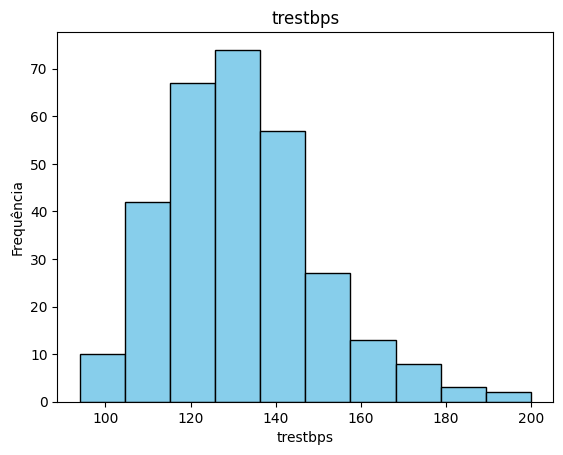

In [43]:
# para observar os bins: trestbps, age, chol, thalach, oldpeak

colunas = ["trestbps", "age", "chol", "thalach", "oldpeak"]

plt.hist(heart_tratado['trestbps'], bins=10, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('trestbps')
plt.xlabel('trestbps')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

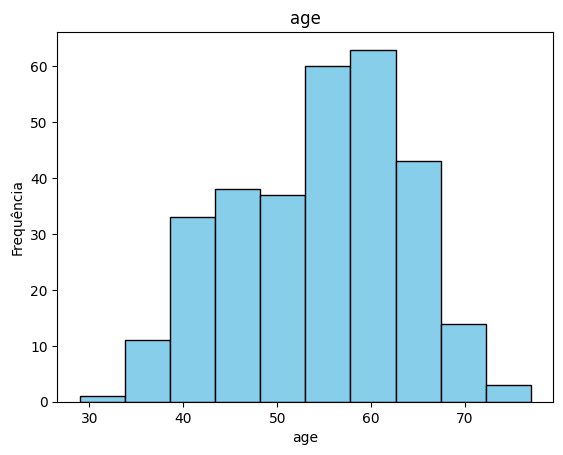

In [47]:
plt.hist(heart_tratado['age'], bins=10, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('age')
plt.xlabel('age')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

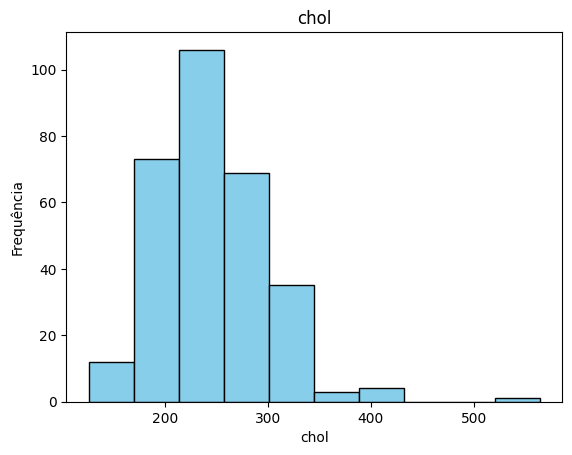

In [ ]:
plt.hist(heart_tratado['chol'], bins=10, color='skyblue', edgecolor='black') # esse talvez seja interessante fazer o standarlization

# Adiciona títulos e rótulos
plt.title('chol')
plt.xlabel('chol')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

In [53]:
heart_tratado['thalach'].value_counts()

thalach
162    11
163     9
160     9
173     8
152     8
       ..
117     1
71      1
118     1
134     1
90      1
Name: count, Length: 91, dtype: int64

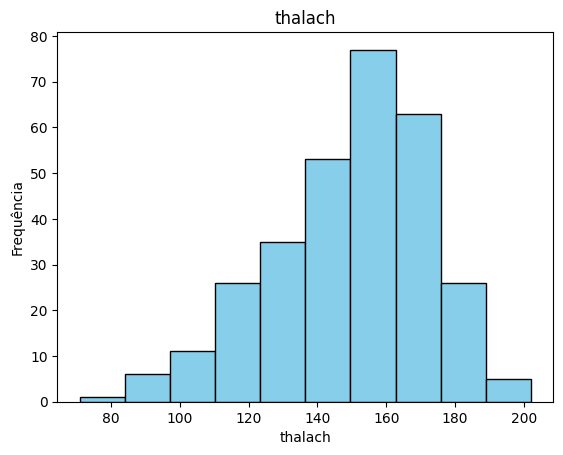

In [52]:
plt.hist(heart_tratado['thalach'], bins=10, color='skyblue', edgecolor='black') # esse talvez seja interessante fazer o standarlization

# Adiciona títulos e rótulos
plt.title('thalach')
plt.xlabel('thalach')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

In [68]:
len(heart_tratado['oldpeak'].value_counts())

40

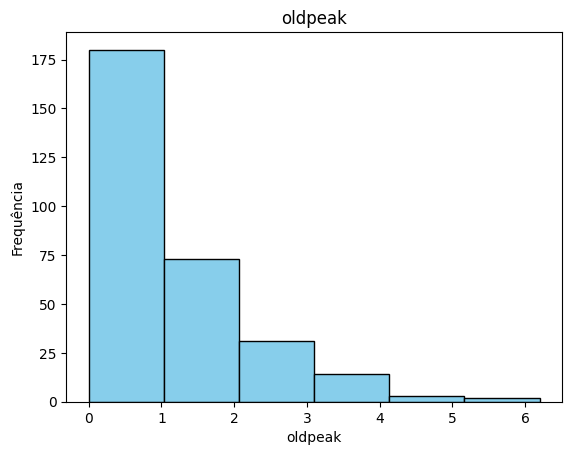

In [69]:

plt.hist(heart_tratado['oldpeak'], bins=6, color='skyblue', edgecolor='black') # esse talvez seja interessante fazer o standarlization

# Adiciona títulos e rótulos
plt.title('oldpeak')
plt.xlabel('oldpeak')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

In [83]:
heart_tratado.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    int64   
 1   sex       303 non-null    bool    
 2   cp        303 non-null    category
 3   trestbps  303 non-null    int64   
 4   chol      303 non-null    int64   
 5   fbs       303 non-null    bool    
 6   restecg   303 non-null    category
 7   thalach   303 non-null    int64   
 8   exang     303 non-null    bool    
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    int64   
 11  ca        303 non-null    int64   
 12  thal      303 non-null    category
 13  target    303 non-null    bool    
 14  age_bin   303 non-null    int64   
 15  chol_bin  303 non-null    int64   
dtypes: bool(4), category(3), float64(1), int64(8)
memory usage: 23.6 KB


In [9]:
heart_tratado['age_bin'] = pd.qcut(heart_tratado['age'], q=10, labels=False, duplicates='drop')
heart_tratado['chol_bin'] = pd.qcut(heart_tratado['chol'], q=10, labels=False, duplicates='drop')

In [11]:
# Rodando XGBoost com as alterações

X = heart_tratado.drop(columns=['target', 'age', 'chol']) 
y = heart_tratado['target']              

# Dividindo em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
y_treino = y_treino.astype(bool)

# Pega o nome das colunas numéricas (int e float)
colunas_numericas = X.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()

# Pega o nome das colunas categóricas (object/string)
colunas_categoricas = X.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

# Pipeline para categorias: aplica One-Hot Encoding
transformer_categorico = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # ignore: se aparecer uma categoria nova no teste, ele não quebra
])

# ColumnTransformer
pre_processador = ColumnTransformer(
    transformers=[
        ('cat', transformer_categorico, colunas_categoricas)
    ])

# Aqui conectamos o tratamento de dados ao modelo Random Forest
modelo_pipeline = Pipeline(steps=[
    # ('pre_processamento', pre_processador),
    ('classificador', XGBClassifier(
        n_estimators=100,     # Número de árvores
        learning_rate=0.1,    # Velocidade de aprendizado (ajuda a não ter overfitting)
        max_depth=5,          # Profundidade máxima de cada árvore
        random_state=42
    ))
])

print("Treinando o modelo...")
modelo_pipeline.fit(X_treino, y_treino)

print("Fazendo previsões no conjunto de teste...")
previsoes = modelo_pipeline.predict(X_teste)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes, digits=5))


Treinando o modelo...
Fazendo previsões no conjunto de teste...

Relatório de Classificação:
              precision    recall  f1-score   support

       False    0.80645   0.86207   0.83333        29
        True    0.86667   0.81250   0.83871        32

    accuracy                        0.83607        61
   macro avg    0.83656   0.83728   0.83602        61
weighted avg    0.83804   0.83607   0.83615        61



## Resultado

Novamente, apenas fazendo a engenharia de dados a acuracia subiu 3 pontos percentuais (sem alterar os parametros nem os dados)


# Conclusão

Nesse trabalho foi possível observar que, melhores dados, bem tratados, conseguem chegar a resultados melhores sem fazer tunning do modelo.
Em ambos os casos foi possível aumentar as métricas de avaliação dos dados.